In [ ]:
from google.colab import files

uploaded = files.upload()

Saving DataSet (W5).csv to DataSet (W5).csv


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("DataSet (W5).csv")

In [ ]:
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [ ]:
df.columns

Index(['rating', 'date', 'variation', 'verified_reviews', 'feedback'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB


In [ ]:
df.isnull().sum()

,0
rating,0
date,0
variation,0
verified_reviews,1
feedback,0


In [ ]:
df[['verified_reviews', 'feedback']].head()

,verified_reviews,feedback
0,Love my Echo!,1
1,Loved it!,1
2,"Sometimes while playing a game, you can answer...",1
3,I have had a lot of fun with this thing. My 4 ...,1
4,Music,1


In [ ]:
df['feedback'].value_counts()

,count
feedback,
1,2893
0,257


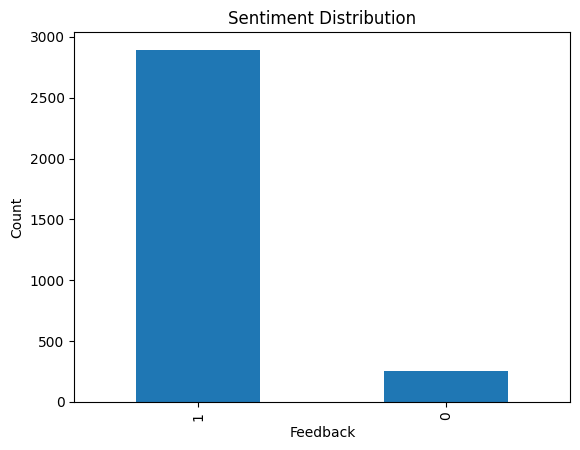

In [ ]:
import matplotlib.pyplot as plt

df['feedback'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Feedback")
plt.ylabel("Count")
plt.show()

## Dataset Inspection

- Review text column: verified_reviews
- Sentiment label column: feedback
- Total records: 3150
- Feedback values:
  - 1 = Positive Review
  - 0 = Negative Review

In [ ]:
!pip install nltk wordcloud

In [ ]:
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):

    # Agar value missing ho
    if pd.isnull(text):
        return ""

    # Small letters
    text = text.lower()

    # Links remove
    text = re.sub(r'http\S+|www\S+', '', text)

    # Numbers remove
    text = re.sub(r'\d+', '', text)

    # Punctuation remove
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Extra spaces remove
    text = text.strip()

    # Stopwords remove + Lemmatization
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

In [ ]:
df['clean_review'] = df['verified_reviews'].apply(clean_text)

In [ ]:
df[['verified_reviews', 'clean_review']].head()

,verified_reviews,clean_review
0,Love my Echo!,love echo
1,Loved it!,loved
2,"Sometimes while playing a game, you can answer...",sometimes playing game answer question correct...
3,I have had a lot of fun with this thing. My 4 ...,lot fun thing yr old learns dinosaur control l...
4,Music,music


## Text Cleaning

The review text was cleaned by:

- Converting text to lowercase.
- Removing URLs.
- Removing numbers.
- Removing punctuation.
- Removing extra spaces.
- Removing English stopwords.
- Applying lemmatization.

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
positive_reviews = " ".join(df[df['feedback'] == 1]['clean_review'])

negative_reviews = " ".join(df[df['feedback'] == 0]['clean_review'])

In [ ]:
positive_wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_reviews)

In [ ]:
negative_wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_reviews)

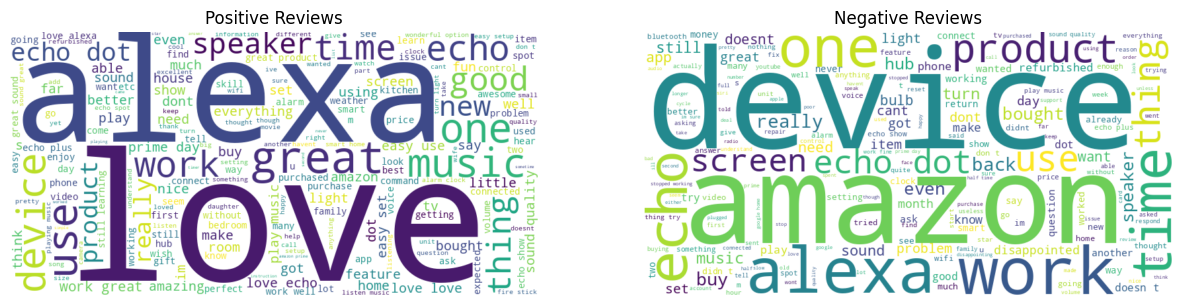

In [ ]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.imshow(positive_wc, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Reviews")

plt.subplot(1,2,2)
plt.imshow(negative_wc, interpolation='bilinear')
plt.axis("off")
plt.title("Negative Reviews")

plt.show()

## Word Cloud Analysis

Two Word Clouds were generated:

- Positive Reviews Word Cloud
- Negative Reviews Word Cloud

These visualizations show the most frequently used words in each sentiment category.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

In [ ]:
X = tfidf.fit_transform(df['clean_review'])

y = df['feedback']

In [ ]:
print(X.shape)
print(y.shape)

(3150, 3853)
(3150,)


## Why TF-IDF?

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical features by giving higher importance to words that are frequent in a review but less common across all reviews. It helps improve text classification performance by reducing the impact of very common words.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
lr_pred = lr_model.predict(X_test)

In [ ]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.9079365079365079


In [ ]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        58
           1       0.91      1.00      0.95       572

    accuracy                           0.91       630
   macro avg       0.45      0.50      0.48       630
weighted avg       0.82      0.91      0.86       630



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


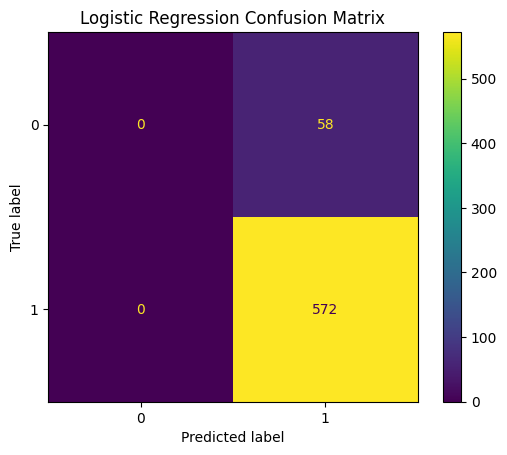

In [ ]:
ConfusionMatrixDisplay.from_estimator(lr_model, X_test, y_test)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
nb_pred = nb_model.predict(X_test)

In [ ]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.9079365079365079


In [ ]:
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        58
           1       0.91      1.00      0.95       572

    accuracy                           0.91       630
   macro avg       0.45      0.50      0.48       630
weighted avg       0.82      0.91      0.86       630



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


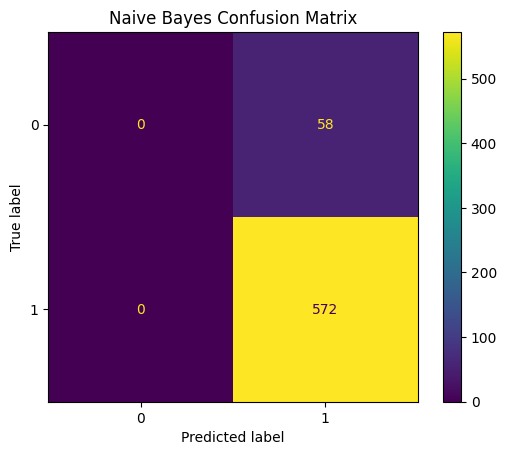

In [ ]:
ConfusionMatrixDisplay.from_estimator(nb_model, X_test, y_test)
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [ ]:
lr_accuracy = accuracy_score(y_test, lr_pred)
nb_accuracy = accuracy_score(y_test, nb_pred)

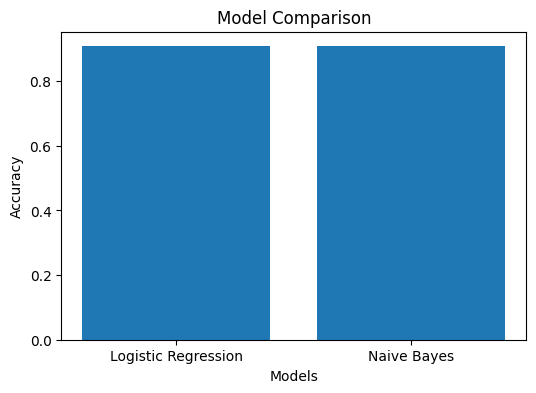

In [ ]:
models = ['Logistic Regression', 'Naive Bayes']
accuracies = [lr_accuracy, nb_accuracy]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
import joblib

In [ ]:
joblib.dump(lr_model, "best_model.pkl")
joblib.dump(tfidf, "vectorizer.pkl")

['vectorizer.pkl']

In [ ]:
joblib.dump(nb_model, "best_model.pkl")
joblib.dump(tfidf, "vectorizer.pkl")

['vectorizer.pkl']

In [ ]:
import os

os.listdir()

['.config',
 'vectorizer.pkl',
 'DataSet (W5).csv',
 'best_model.pkl',
 'sample_data']